<a href="https://colab.research.google.com/github/DammuNikhitha/AI-ML-Internship-Task-6/blob/main/01_Task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 6 :  Linear Regression – House Price Prediction
##Tools:
Python, Pandas, NumPy
Scikit-learn
Matplotlib
##Dataset:
House Prices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: Load California Housing Dataset

The dataset is loaded using Scikit-learn and converted into a Pandas DataFrame for easier exploration and manipulation.


In [2]:
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedianHouseValue'] = housing.target

# Step 2: Basic Data Inspection
We inspect the dataset using:

*  .head() to view sample rows

*   .info() to understand data types and null values
*   .describe() to analyze statistical ranges




In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   MedianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**🔍 Observation:**

*   All features are numerical
*   No missing values
*   Target variable is continuous



#Step 3: Separate Features (X) and Target (y)
We separate:
*  X (features) → independent variables

*   y (target) → median house value
*   This separation is required before model training.



In [6]:
X = df.drop('MedianHouseValue', axis=1)
y = df['MedianHouseValue']

print(type(y), y.head())

<class 'pandas.core.series.Series'> 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedianHouseValue, dtype: float64


✔️ y is continuous → Linear Regression is suitable

#Step 4: Train-Test Split

The dataset is split into:
*   80% Training data
*   20% Testing data

##Why split the data?
Training data is used to learn patterns.
*   Training data is used to learn patterns
*   Testing data is used to evaluate model performance on unseen data
*   A fixed random_state ensures reproducibility.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


#Step 5: Train Linear Regression Model
A Linear Regression model is created and trained using the training dataset.

Linear Regression learns the best-fit line by minimizing prediction error.


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#Step 6: Prediction & Comparison
The trained model predicts house prices on the test dataset.

A comparison table of actual vs predicted values is created to visually check model accuracy.

In [10]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10]
})
comparison

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


#Step 7: Model Evaluation (MAE & RMSE)
Two regression evaluation metrics are used:

**MAE (Mean Absolute Error):**
Measures average absolute difference between actual and predicted values.

**RMSE (Root Mean Squared Error):**
Penalizes larger errors and is more sensitive to outliers.
Lower values indicate better model performance.


In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.5332001304956553
Root Mean Squared Error (RMSE): 0.7455813830127764


#Step 8: Actual vs Predicted Visualization
A scatter plot is used to compare actual and predicted house prices.

Interpretation:
Points closer to the diagonal indicate accurate predictions.

Wide spread indicates higher prediction error.

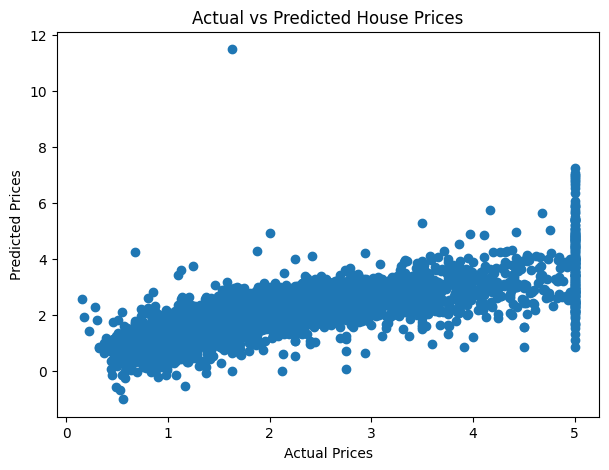

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

**🔍 Observation:**
Points closer to diagonal line → better predictions

#Step 9: Interpretation of Model Coefficients
Model coefficients show the impact of each feature on house price prediction.

Interpretation:
* Positive coefficient: Increases
house price
* Negative coefficient: Decreases house price
* Higher magnitude → more influence

In [13]:
coefficients = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708
